# RQ1 — Data Quality Characteristics [Q9, Q11, Q13, Q16]

The Questions Q10, Q12, Q14, Q15 are all open questions, and thir analysis was qualitative. Analysis in data\codebook

## Q9 - Top 5 words

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd()))
import utils as U
import pandas as pd

U.setup_matplotlib()
TABLES = U.DATA_PROC / "tables"
TABLES.mkdir(exist_ok=True)

df = U.load_anonymized()
imp_long = pd.read_csv(U.DATA_PROC / "likert_importance.csv")
pri_long = pd.read_csv(U.DATA_PROC / "likert_priority.csv")
skills_long = pd.read_csv(U.DATA_PROC / "skills.csv")
words_long = pd.read_csv(U.DATA_PROC / "words.csv")
print(f"N={len(df)}, importance={len(imp_long)}, priority={len(pri_long)}, tokens Q9={len(words_long)}")


N=56, importance=728, priority=728, tokens Q9=279


In [2]:
_CANDIDATE_COLS = ["canonical", "word", "palavra", "term", "token", "label"]
_WORD_COL = next((c for c in _CANDIDATE_COLS if c in words_long.columns), None)

if _WORD_COL is None:
    raise ValueError(
        f"Nenhuma coluna de palavras encontrada em words_long. "
        f"Colunas disponíveis: {list(words_long.columns)}"
    )

TOP_N = 5

words_long_en = words_long.copy()
words_long_en = words_long_en[words_long_en[_WORD_COL].apply(U.is_valid_word)].copy()
words_long_en[_WORD_COL] = words_long_en[_WORD_COL].apply(U.normalize_to_en)

by_pos_full = (
    words_long_en
    .groupby([_WORD_COL, "position"])
    .size()
    .unstack(fill_value=0)
)

positions = [1, 2, 3, 4, 5]
top_words_per_pos = {}
for pos in positions:
    if pos in by_pos_full.columns:
        top_words_per_pos[pos] = by_pos_full[pos].nlargest(TOP_N)

all_top_words = sorted(set(
    w for words in top_words_per_pos.values() for w in words.index
))

cmap = plt.cm.get_cmap('tab20', len(all_top_words))
word_colors = {w: cmap(i) for i, w in enumerate(all_top_words)}

C:\Users\kevin\AppData\Local\Temp\ipykernel_20196\1351392925.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(all_top_words))


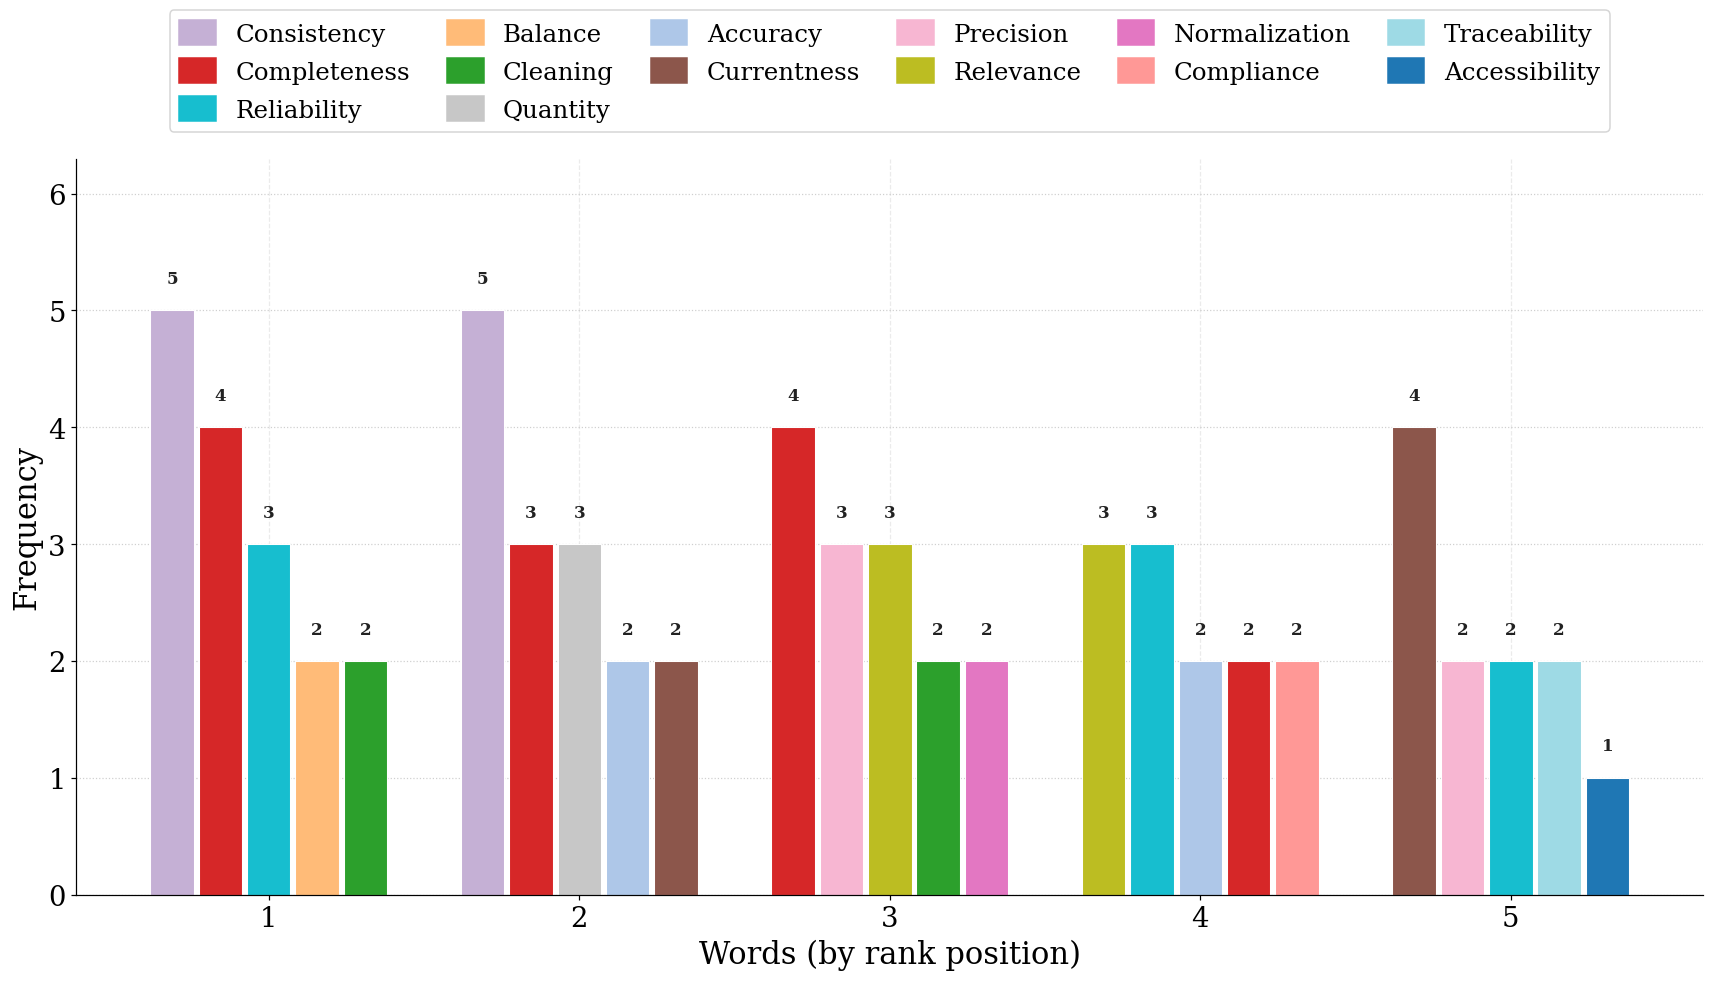

In [3]:
U.setup_matplotlib()

fig, ax = plt.subplots(figsize=(16, 9))

bar_width = 0.07
group_gap = 0.1
legend_handles = {}

for g_idx, pos in enumerate(positions):
    if pos not in top_words_per_pos:
        continue

    words_in_pos = top_words_per_pos[pos]
    group_center = g_idx * (TOP_N * bar_width + group_gap)

    for b_idx, (word, freq) in enumerate(words_in_pos.items()):
        x = group_center + b_idx * bar_width
        color = word_colors[word]

        ax.bar(x, freq, width=bar_width * 0.9,
               color=color, edgecolor='white', linewidth=0.7)

        if word not in legend_handles:
            legend_handles[word] = plt.Rectangle((0, 0), 1, 1, color=color)

        ax.text(x, freq + 0.2, str(int(freq)),
                ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='#222222')

group_centers = [
    g * (TOP_N * bar_width + group_gap) + (TOP_N - 1) * bar_width / 2
    for g in range(len(positions))
]

ax.set_xticks(group_centers)
ax.set_xticklabels([str(p) for p in positions], fontsize=18)

ax.set_xlabel("Words (by rank position)", fontsize=20)
ax.set_ylabel("Frequency", fontsize=20)

ax.tick_params(axis='y', labelsize=18)

ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle=':', alpha=0.6)
ax.set_axisbelow(True)
ax.set_ylim(0, ax.get_ylim()[1] * 1.2)

ax.legend(
    legend_handles.values(), legend_handles.keys(),
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=6,
    frameon=True,
    fontsize=16,
    handlelength=1.5,
    handleheight=1.2,
    columnspacing=1.5
)

plt.tight_layout()
U.save_fig(fig, "../figures/q9_top_words_by_position.pdf")
plt.show()

## Q11 & Q13— Importance, Priority of Data Quality Characteristics

In [4]:
from matplotlib import rcParams

rcParams["font.family"]      = "sans-serif"
rcParams["font.sans-serif"]  = ["DejaVu Sans", "Arial", "Helvetica", "Liberation Sans"]
rcParams["mathtext.fontset"] = "dejavusans"

C:\Users\kevin\AppData\Local\Temp\ipykernel_20196\2426214696.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


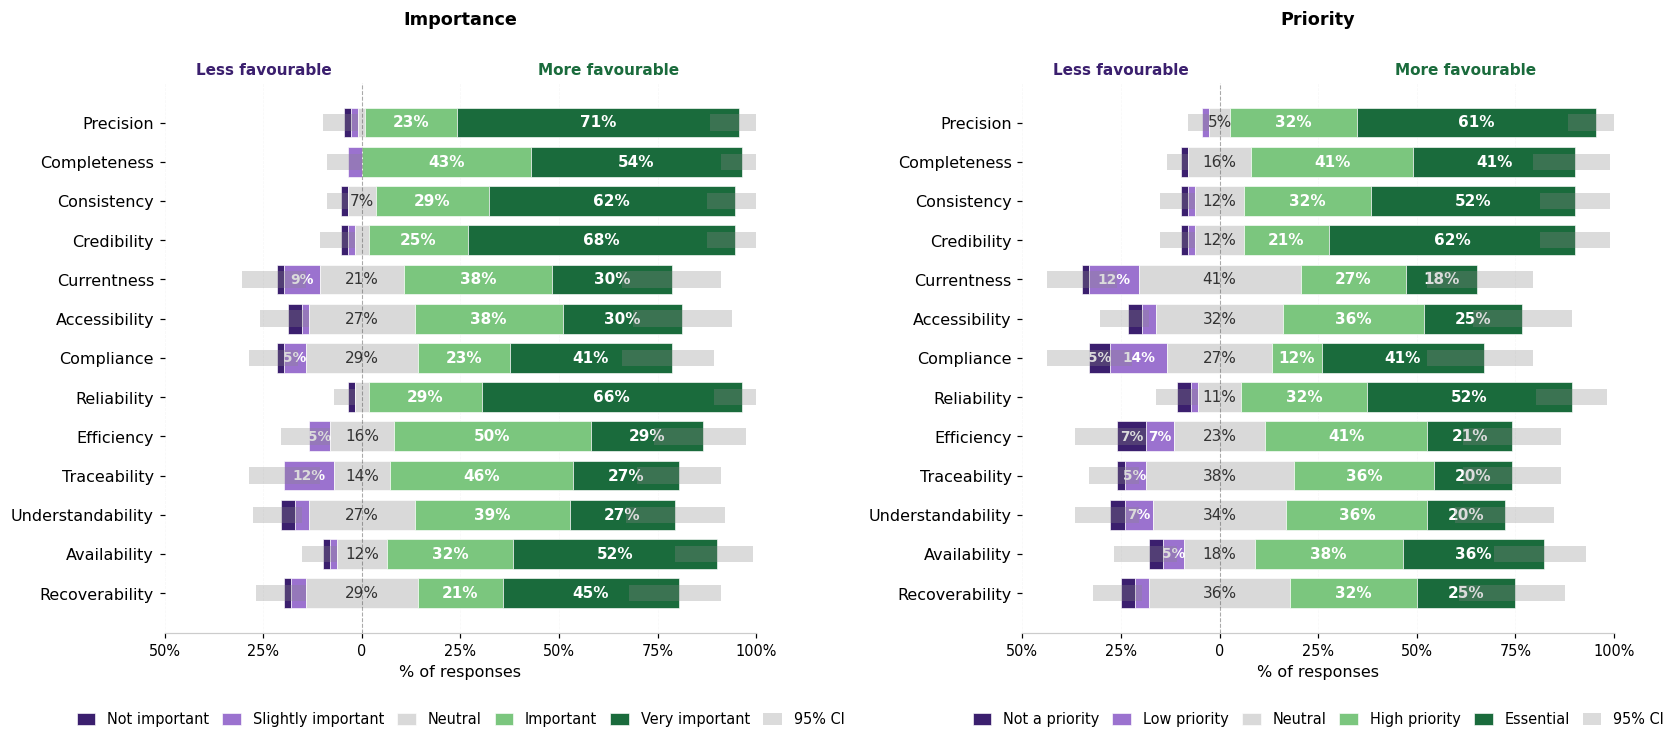

In [5]:
_imp_ci = U._bootstrap_ci(
    imp_long, "characteristic", "importance",
    list(U.CHARACTERISTICS_PT.keys()),
    top_levels=[4, 5], bottom_levels=[1, 2]
)
_pri_ci = U._bootstrap_ci(
    pri_long, "characteristic", "priority",
    list(U.CHARACTERISTICS_PT.keys()),
    top_levels=[4, 5], bottom_levels=[1, 2]
)

fig, (ax_imp, ax_pri) = plt.subplots(1, 2, figsize=(17.0, 6.5), gridspec_kw={"wspace": 0.45})

U.diverging_stacked(
    imp_long,
    item_col="characteristic",
    value_col="importance",
    item_labels=U.CHARACTERISTICS_PT,
    level_labels=["Not important", "Slightly important", "Neutral", "Important", "Very important"],
    ci_df=_imp_ci,
    ax=ax_imp,
    title="Importance",
)

U.diverging_stacked(
    pri_long,
    item_col="characteristic",
    value_col="priority",
    item_labels=U.CHARACTERISTICS_PT,
    level_labels=["Not a priority", "Low priority", "Neutral", "High priority", "Essential"],
    ci_df=_pri_ci,
    ax=ax_pri,
    title="Priority",
)

fig.tight_layout()
U.save_fig(fig, "importance_priority_diverging")
plt.show()

## Spearman Rank Correlation — Importance × Priority (Complementar analysis for Q11 & Q13)


In [6]:
from scipy.stats import shapiro
rng = np.random.default_rng(42)

# Step 1 — Shapiro-Wilk: confirm non-normality to justify Spearman
sw_results = []
for col_imp, col_pri in zip(U.IMP_COLS, U.PRI_COLS):
    char = col_imp.split("_", 1)[1]
    _, p_imp = shapiro(df[col_imp].dropna())
    _, p_pri = shapiro(df[col_pri].dropna())
    sw_results.append({
        "characteristic": char,
        "p_imp": p_imp, "normal_imp": p_imp >= 0.05,
        "p_pri": p_pri, "normal_pri": p_pri >= 0.05
    })

sw_df = pd.DataFrame(sw_results)
n_nn_imp = (~sw_df["normal_imp"]).sum()
n_nn_pri = (~sw_df["normal_pri"]).sum()

print(f"(IMP) Shapiro-Wilk: {n_nn_imp}/13 importance distributions non-normal (p<0.05)")
print(f"(PRI) Shapiro-Wilk: {n_nn_pri}/13 priority distributions non-normal (p<0.05)")
print("→ Non-normal distributions justify Spearman's rank correlation.\n")

(IMP) Shapiro-Wilk: 13/13 importance distributions non-normal (p<0.05)
(PRI) Shapiro-Wilk: 13/13 priority distributions non-normal (p<0.05)
→ Non-normal distributions justify Spearman's rank correlation.



In [7]:
spearman_rows = []
for col_imp, col_pri in zip(U.IMP_COLS, U.PRI_COLS):
    char = col_imp.split("_", 1)[1]
    mask = df[col_imp].notna() & df[col_pri].notna()
    from scipy.stats import spearmanr
    rho, p = spearmanr(df.loc[mask, col_imp], df.loc[mask, col_pri])

    spearman_rows.append({
        "characteristic": char,
        "n": int(mask.sum()),
        "rho": float(rho),
        "p": float(p),
        "sig": float(p) < 0.05,
        "strength": U._salkind_strength(float(rho)),
    })

spearman_df = pd.DataFrame(spearman_rows)

n_sig = spearman_df["sig"].sum()
print(f"H1 — significant (p<0.05): {n_sig}/13 characteristics")

H1 — significant (p<0.05): 13/13 characteristics


raw form

In [8]:
spearman_out = spearman_df[["characteristic", "rho", "strength", "p"]]

display(
    spearman_out.style
    .hide(axis="index")
    .format({"rho": "{:.6f}", "p": "{:.6f}"})
)

_caption = (
    "Spearman's rank correlation coefficient ($\\rho$) between Importance (Q11) "
    "and Priority (Q13) for each data quality characteristic. "
    "Confidence level: 95\\% ($p < 0.05$). "
    "Correlation strength classification follows Salkind (2012)."
)
_label = "tab:spearman-imp-pri"

_body = (
    spearman_out.style
    .hide(axis="index")
    .format({"rho": "{:.6f}", "p": "{:.6f}"})
    .to_latex(hrules=True, column_format="lrlr")
)

_tex = (
    "\\begin{table}[t]\n"
    f"  \\caption{{{_caption}}}\n"
    f"  \\label{{{_label}}}\n"
    "  \\centering\n"
    "  \\small\n"
    + _body +
    "\\end{table}\n"
)

(TABLES / "spearman_imp_vs_pri.tex").write_text(_tex, encoding="utf-8")
print("[saved] tables/spearman_imp_vs_pri.tex")

characteristic,rho,strength,p
precision,0.637028,Strong,0.000000
completeness,0.584710,Moderate,0.000002
consistency,0.588942,Moderate,0.000002
credibility,0.573436,Moderate,0.000004
currentness,0.713666,Strong,0.000000
accessibility,0.541869,Moderate,0.000016
compliance,0.832055,Very Strong,0.000000
reliability,0.543933,Moderate,0.000015
efficiency,0.525832,Moderate,0.000032
traceability,0.692552,Strong,0.000000


[saved] tables/spearman_imp_vs_pri.tex


## Q16 - Data version control impact data quality characteristics 

In [9]:
raw = pd.read_excel(U.DATA_RAW / "full_quali.xlsx", engine="openpyxl")

q16 = raw["versioning_open"].value_counts(dropna=False)
n_total = len(raw)

labels = [str(resp) if pd.notna(resp) else "(no answer)" for resp in q16.index]
label_width = max(len("Response"), max(len(l) for l in labels))

print(f"Q16 — Data version control impact on data quality (N={n_total})\n")
print(f"{'Response':<{label_width}}  {'n':>6}  {'%':>7}")
print("-" * (label_width + 16))

for resp, n in q16.items():
    label = str(resp) if pd.notna(resp) else "(no answer)"
    pct = n / n_total * 100
    print(f"{label:<{label_width}}  {n:>6}  {pct:>6.1f}%")

print("-" * (label_width + 16))
print(f"{'Total':<{label_width}}  {n_total:>6}  {100:>6.1f}%")

Q16 — Data version control impact on data quality (N=56)

Response                                                                                                                  n        %
-----------------------------------------------------------------------------------------------------------------------------------
Ensures data consistency and traceability over time, allowing changes to the dataset to be documented and verified.      51    91.1%
Eliminates the need to document changes to the dataset, as all changes are automatically applied to the model.            3     5.4%
Increases the amount of data available, without the need to check consistency between versions.                           1     1.8%
I have no experience in this regard                                                                                       1     1.8%
-----------------------------------------------------------------------------------------------------------------------------------
Total        